In [14]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [15]:
df=pd.read_csv('penguins.csv')
df

,Unnamed: 0,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,1,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,2,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,3,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,4,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,5,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
...,...,...,...,...,...,...,...,...,...
339,340,Chinstrap,Dream,55.8,19.8,207.0,4000.0,male,2009
340,341,Chinstrap,Dream,43.5,18.1,202.0,3400.0,female,2009
341,342,Chinstrap,Dream,49.6,18.2,193.0,3775.0,male,2009
342,343,Chinstrap,Dream,50.8,19.0,210.0,4100.0,male,2009


<Axes: xlabel='bill_length_mm', ylabel='flipper_length_mm'>

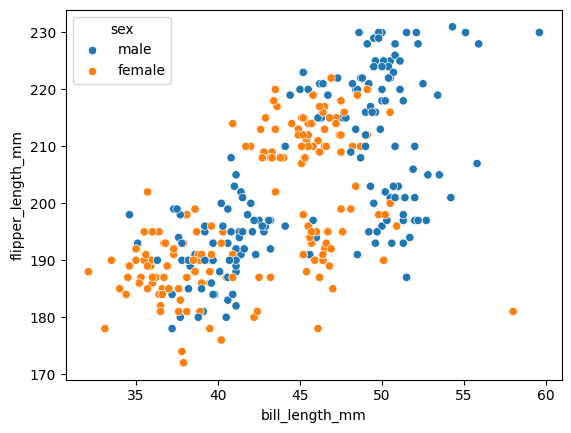

In [16]:
sns.scatterplot(x=df['bill_length_mm'], y=df['flipper_length_mm'], hue=df['sex'])

In [17]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


In [18]:
df_numerical = df[[
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g"
]]

In [19]:
df_clean = df_numerical.dropna()

In [20]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_clean)


In [21]:
wcss=[]

for i in range(1,11):
    km = KMeans(n_clusters=i)
    km.fit_predict(df_scaled)
    wcss.append(km.inertia_)

In [22]:
wcss

[1367.9999999999998,
 565.7076453796292,
 486.2024496039381,
 300.52111869101026,
 232.75817718615627,
 267.396304325018,
 199.79044007693912,
 178.35629433901198,
 168.5762236708469,
 150.0841376542724]

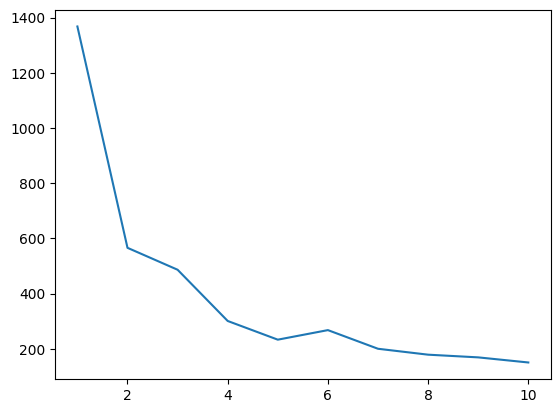

In [23]:
plt.plot(range(1,11), wcss)

In [24]:
kmeans = KMeans(n_clusters=3, random_state=43)
clusters = kmeans.fit_predict(df_scaled)


In [25]:
df_clean["Cluster"] = clusters
df_clean.head()

C:\Users\soumil\AppData\Local\Temp\ipykernel_31924\1524288163.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,Cluster
0,39.1,18.7,181.0,3750.0,0
1,39.5,17.4,186.0,3800.0,0
2,40.3,18.0,195.0,3250.0,0
4,36.7,19.3,193.0,3450.0,0
5,39.3,20.6,190.0,3650.0,0


In [26]:
fig = px.scatter_3d(
    df_clean,
    x="bill_length_mm",
    y="bill_depth_mm",
    z="flipper_length_mm",
    color="body_mass_g",   # 4th feature as hue
    title="Interactive 3D Plot: 3 Features + Body Mass as Hue",
    labels={
        "bill_length_mm": "Bill Length (mm)",
        "bill_depth_mm": "Bill Depth (mm)",
        "flipper_length_mm": "Flipper Length (mm)",
        "body_mass_g": "Body Mass (g)"
    }
)

fig.show()